# Credit Card Fraud Detection - Machine Learning Pipeline

## Project Overview
This notebook builds and compares multiple machine learning models to detect fraudulent credit card transactions.

**Dataset**: 284,807 credit card transactions with 31 features  
**Models**: 4 classifiers - Logistic Regression, Random Forest, SVM, K-Nearest Neighbors  
**Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC  
**Goal**: Build an effective fraud detection system that maximizes fraud detection while minimizing false alarms

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

## Step 1: Import Required Libraries
Load all necessary Python libraries for:
- **Data handling**: NumPy, Pandas
- **Visualization**: Matplotlib, Seaborn
- **Machine Learning**: Scikit-learn (algorithms, metrics, preprocessing)
- **Preprocessing**: RobustScaler for feature scaling

In [ ]:
# Load and preprocess data
df = pd.read_csv('creditcard.csv')

# Scale Amount and Time features
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['Class'].value_counts()}")

Dataset shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## Step 2: Load and Preprocess Data
**Actions:**
1. Read `creditcard.csv` into a pandas DataFrame
2. Scale `Amount` and `Time` features using RobustScaler (more resistant to outliers than StandardScaler)
3. Remove original unscaled columns
4. Print dataset dimensions and class distribution (normal vs fraudulent transactions)

In [ ]:
# Train-test split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (227845, 30)
Test set size: (56962, 30)


## Step 3: Train-Test Split
Divide data into training and testing sets:
- **Training Data (80%)**: Used to train all machine learning models
- **Testing Data (20%)**: Reserved for unbiased model evaluation
- **Stratification**: Ensures both train and test sets have similar fraud/normal ratios
- Prevents data leakage and enables accurate performance measurement

In [ ]:
# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 4: Train Baseline Model - Logistic Regression
**Why Logistic Regression?**
- Fast training on large datasets
- Highly interpretable results
- Excellent baseline for binary classification
- Provides probability estimates for fraud likelihood

In [ ]:
# Test and evaluate Logistic Regression
y_pred_lr = model.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nConfusion Matrix:\n{cm_lr}")

Logistic Regression Accuracy: 0.9991 (99.91%)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56850    14]
 [   35    63]]


## Step 5: Evaluate Baseline Model Performance
**Classification Metrics:**
- **Accuracy**: Overall correctness (WARNING: can be misleading with imbalanced fraud data)
- **Precision**: Of all predicted frauds, what % were actually fraudulent?
- **Recall**: Of all actual frauds, what % did we correctly identify?
- **F1-Score**: Harmonic mean balancing precision and recall

**Confusion Matrix Breakdown:**
- True Negatives (TN): Correctly identified normal transactions
- False Positives (FP): Normal transactions incorrectly flagged as fraud
- False Negatives (FN): Actual frauds missed by the model
- True Positives (TP): Correctly identified fraudulent transactions

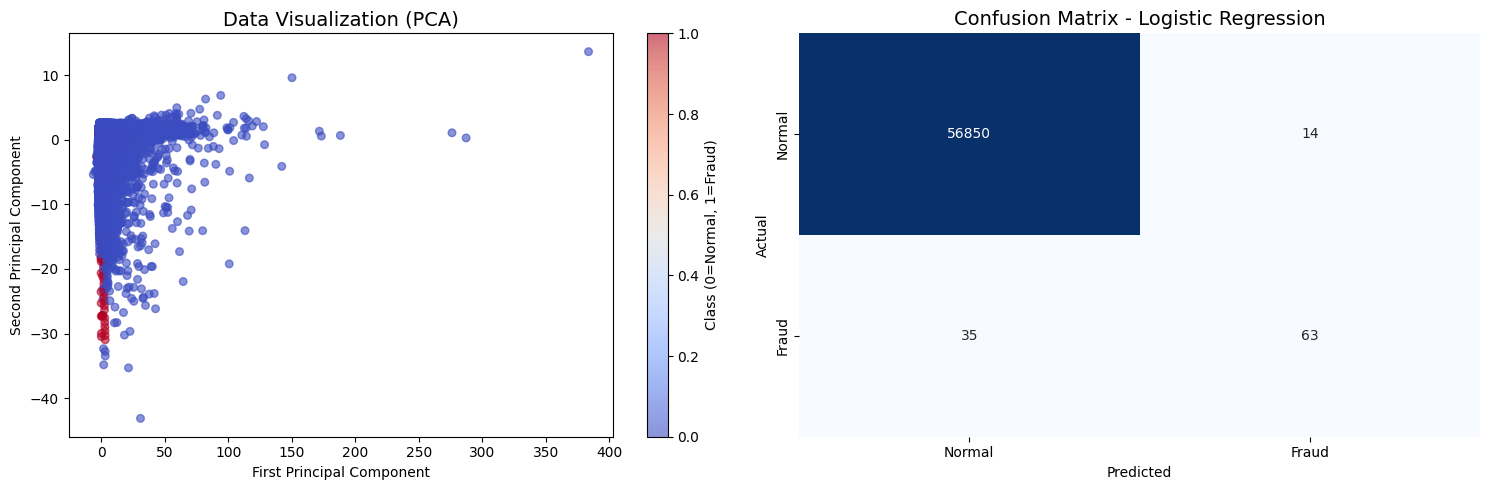


PCA Explained Variance Ratio: [0.32620555 0.08638223]


In [ ]:
# Visualize data using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA plot
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=30)
axes[0].set_title('Data Visualization (PCA)', fontsize=14)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
plt.colorbar(scatter, ax=axes[0], label='Class (0=Normal, 1=Fraud)')

# Confusion Matrix Heatmap (Logistic Regression)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, 
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title('Confusion Matrix - Logistic Regression', fontsize=14)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance Ratio: {pca.explained_variance_ratio_}")

## Step 6: Visualize Data Using PCA
**Principal Component Analysis (PCA):**
- Reduces 30 original features down to 2 principal components
- Enables 2D visualization of high-dimensional data
- Shows spatial separation between fraudulent and normal transactions
- Displays confusion matrix heatmap for Logistic Regression results

In [ ]:
# Train multiple models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)\n")

# Support Vector Machine
print("Training SVM...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)\n")

# K-Nearest Neighbors
print("Training K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn:.4f} ({accuracy_knn*100:.2f}%)\n")

# Store results
models = {
    'Logistic Regression': {'accuracy': accuracy_lr, 'predictions': y_pred_lr, 'cm': cm_lr},
    'Random Forest': {'accuracy': accuracy_rf, 'predictions': y_pred_rf, 'cm': cm_rf},
    'SVM': {'accuracy': accuracy_svm, 'predictions': y_pred_svm, 'cm': cm_svm},
    'KNN': {'accuracy': accuracy_knn, 'predictions': y_pred_knn, 'cm': cm_knn}
}

print("All models trained successfully!")

Training Random Forest...
Random Forest Accuracy: 0.9996 (99.96%)

Training SVM...
SVM Accuracy: 0.9994 (99.94%)

Training K-Nearest Neighbors...
KNN Accuracy: 0.9995 (99.95%)

All models trained successfully!


## Step 7: Train Additional Classification Models
Expand evaluation by training three complementary algorithms:

1. **Random Forest**: Ensemble of 100 decision trees
   - Captures non-linear patterns through multiple perspectives

   - Robust to outliers and feature interactions   - Effective for local pattern recognition

   - Feature importance ranking   - Fast prediction phase, no training assumptions

   - Instance-based learning using proximity

2. **Support Vector Machine (SVM)**: RBF kernel3. **K-Nearest Neighbors (KNN)**: k=5

   - Finds optimal hyperplane maximizing margins between classes

   - Handles high-dimensional data well   - Powerful for non-linear separation

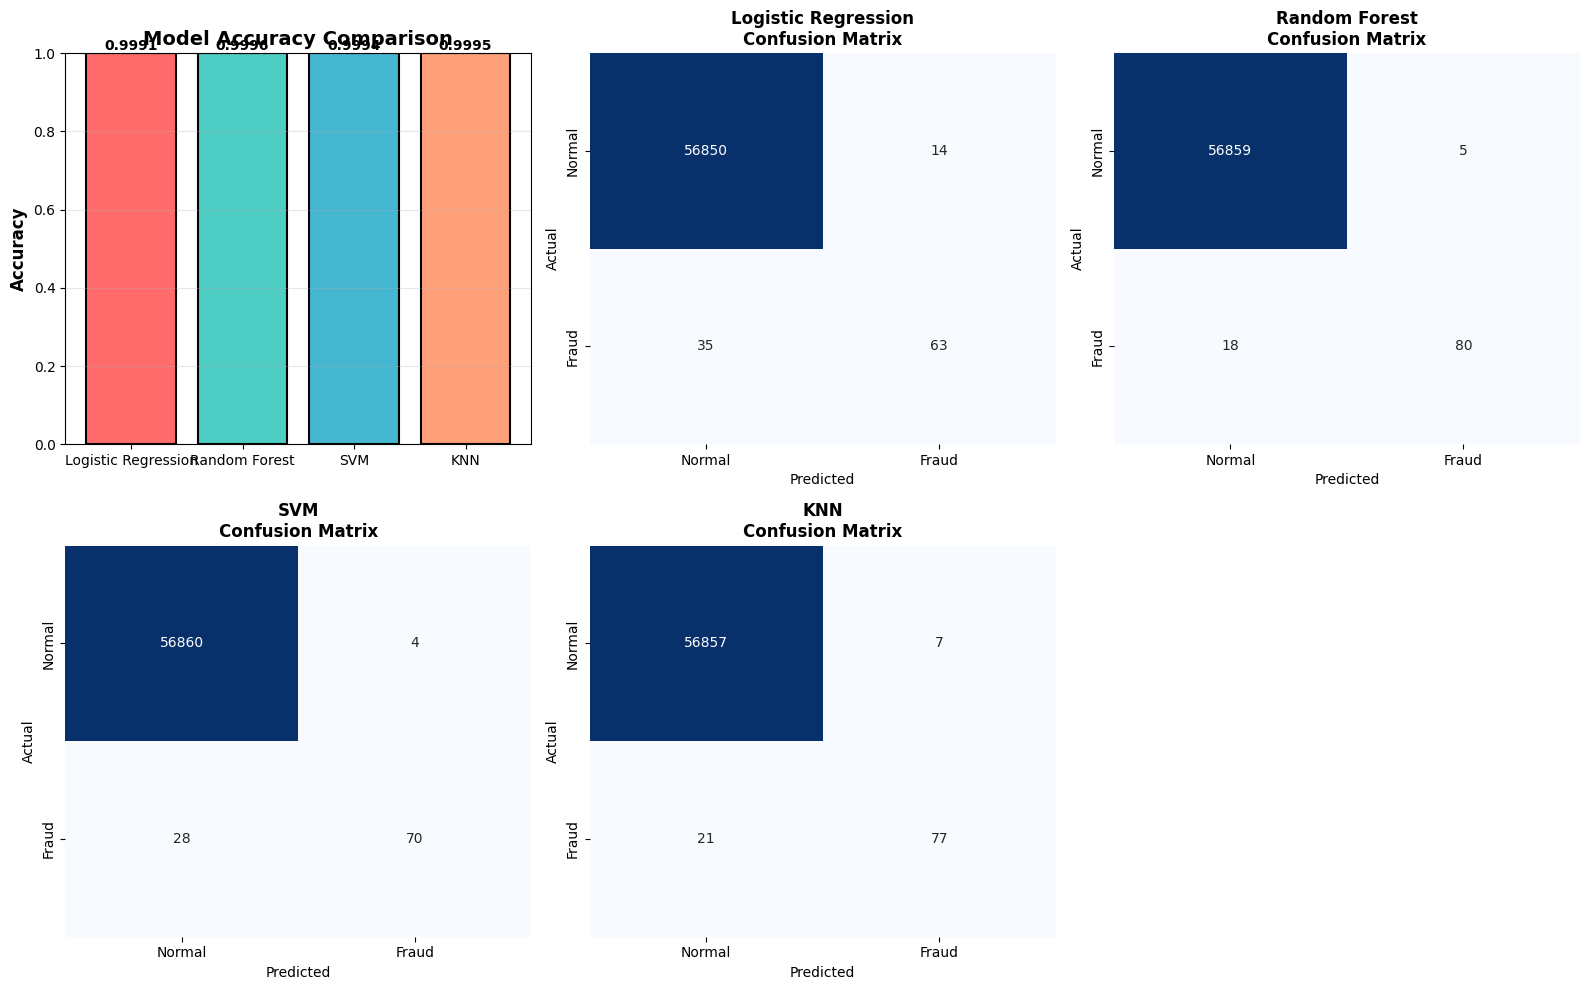


MODEL COMPARISON SUMMARY
Logistic Regression: 0.9991 (99.91%)
Random Forest: 0.9996 (99.96%)
SVM: 0.9994 (99.94%)
KNN: 0.9995 (99.95%)


In [ ]:
# Compare models - Accuracy bar chart + Confusion matrices
fig = plt.figure(figsize=(16, 10))

# Accuracy Comparison
ax1 = plt.subplot(2, 3, 1)
model_names = list(models.keys())
accuracies = [models[m]['accuracy'] for m in model_names]
colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax1.bar(model_names, accuracies, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Confusion matrices
cms = [cm_lr, cm_rf, cm_svm, cm_knn]
titles = model_names

for idx, (cm, title) in enumerate(zip(cms, titles), start=2):
    ax = plt.subplot(2, 3, idx)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, 
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
for model_name, model_data in models.items():
    print(f"{model_name}: {model_data['accuracy']:.4f} ({model_data['accuracy']*100:.2f}%)")

## Step 8: Model Accuracy Comparison
**Visualization Components:**
- **Accuracy Bar Chart**: Direct comparison of all 4 models' overall correctness
- **4 Confusion Matrices**: One for each model showing:
  - True/False Positives and Negatives
  - Error patterns specific to each algorithm
- **Purpose**: Quick identification of best-performing model

## Step 9: Detailed Metrics and Individual ROC Curves
**Comprehensive Performance Analysis:**
- Calculate Precision, Recall, F1-Score for each model individually
- Generate ROC (Receiver Operating Characteristic) curves
- Compute AUC (Area Under Curve) - single metric for model comparison
- Individual 2x2 subplot grid showing each model's ROC curve with AUC score
- ROC curves show trade-off between True Positive Rate and False Positive Rate


DETAILED METRICS FOR ALL MODELS:

Logistic Regression:
  Precision: 0.8182
  Recall:    0.6429
  F1-Score:  0.7200
  ROC-AUC:   0.9582

Random Forest:
  Precision: 0.9412
  Recall:    0.8163
  F1-Score:  0.8743
  ROC-AUC:   0.9528

SVM:
  Precision: 0.9459
  Recall:    0.7143
  F1-Score:  0.8140
  ROC-AUC:   0.9691

KNN:
  Precision: 0.9167
  Recall:    0.7857
  F1-Score:  0.8462
  ROC-AUC:   0.9438


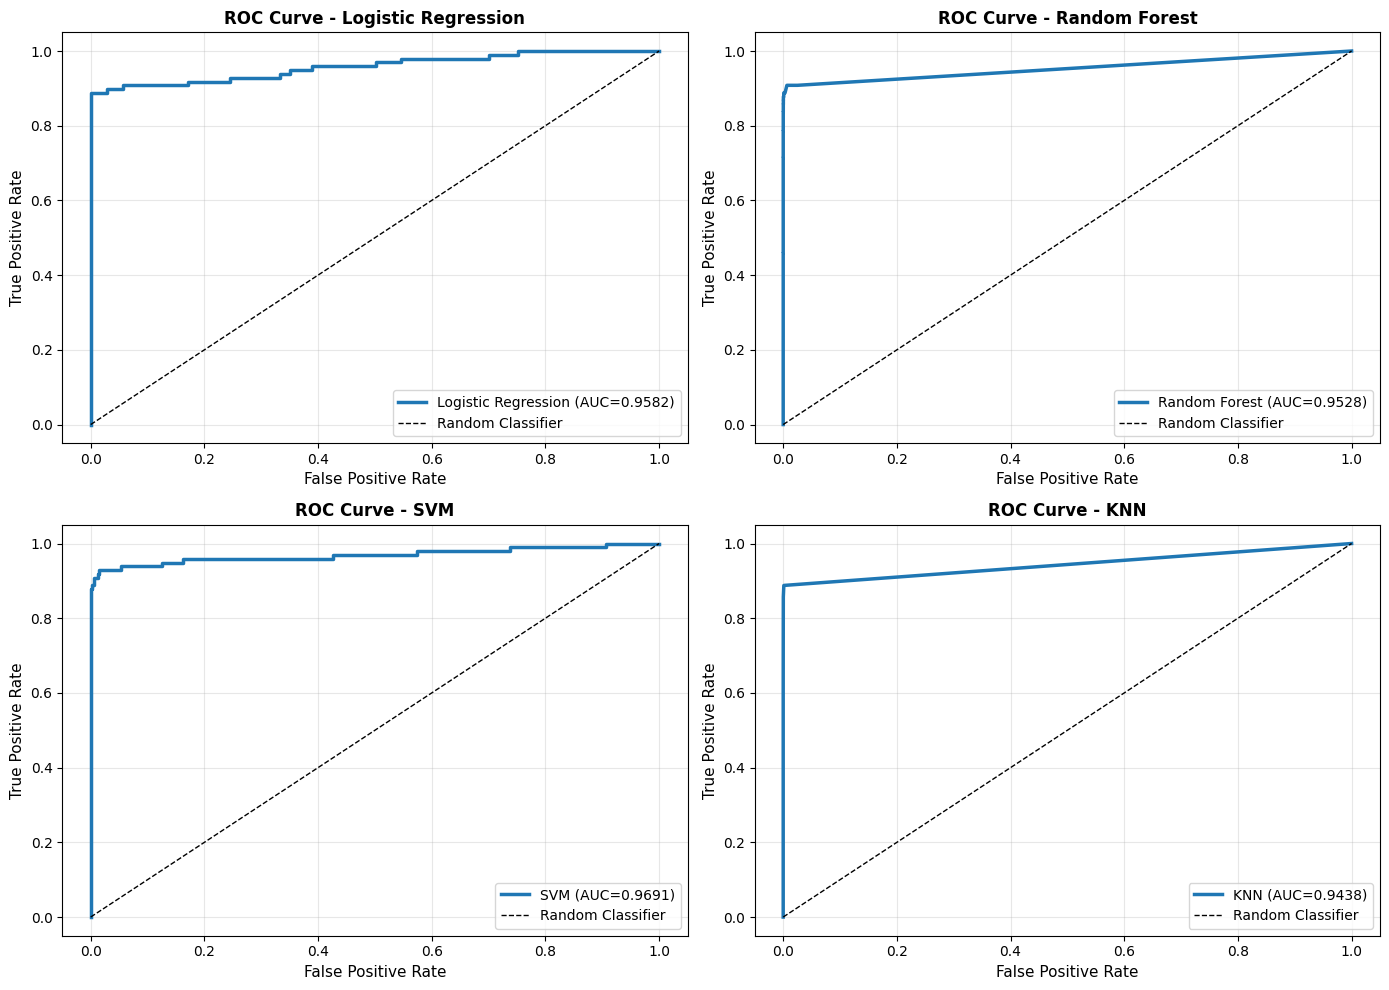

In [ ]:
# Detailed metrics comparison
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

metrics_data = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("\nDETAILED METRICS FOR ALL MODELS:")
print("="*70)

model_list = [
    ('Logistic Regression', y_pred_lr, model, 'LR'),
    ('Random Forest', y_pred_rf, rf_model, 'RF'),
    ('SVM', y_pred_svm, svm_model, 'SVM'),
    ('KNN', y_pred_knn, knn_model, 'KNN')
]

for idx, (name, y_pred, model_obj, label) in enumerate(model_list):
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Get probability scores for ROC curve (if available)
    try:
        y_scores = model_obj.predict_proba(X_test)[:, 1]
    except:
        y_scores = model_obj.decision_function(X_test)
    
    roc_auc = roc_auc_score(y_test, y_scores)
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    
    metrics_data[name] = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr
    }
    
    print(f"\n{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Plot ROC curve
    ax = axes[idx]
    ax.plot(metrics_data[name]['fpr'], metrics_data[name]['tpr'], 
            linewidth=2.5, label=f'{name} (AUC={roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve - {name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)

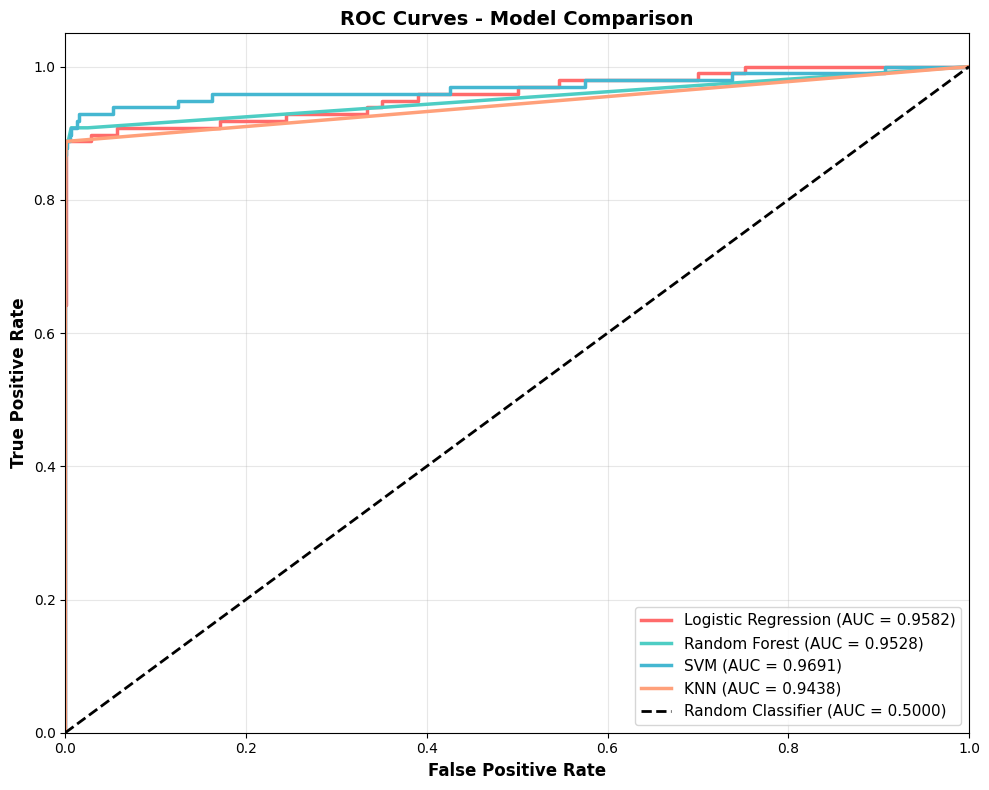

All models plotted on single ROC curve for easy comparison


In [ ]:
# Combined ROC Curves - All Models Comparison
plt.figure(figsize=(10, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
model_names_list = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN']

# Plot each model's ROC curve
for idx, (name, color) in enumerate(zip(model_names_list, colors)):
    fpr = metrics_data[name]['fpr']
    tpr = metrics_data[name]['tpr']
    roc_auc = metrics_data[name]['roc_auc']
    plt.plot(fpr, tpr, linewidth=2.5, color=color, 
             label=f'{name} (AUC = {roc_auc:.4f})')

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("All models plotted on single ROC curve for easy comparison")

## Step 10: Combined ROC Curves - Model Comparison
**Single Plot Analysis:**
- All 4 models plotted on one figure for direct comparison
- Each model labeled with its AUC score
- Reference line at 0.5 represents random guessing
- **Interpretation**: Models closer to top-left corner have better discrimination
- Higher AUC = Better ability to distinguish fraud from normal transactions


COMPREHENSIVE METRICS COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.999140   0.818182 0.642857  0.720000 0.958185
      Random Forest  0.999596   0.941176 0.816327  0.874317 0.952793
                SVM  0.999438   0.945946 0.714286  0.813953 0.969082
                KNN  0.999508   0.916667 0.785714  0.846154 0.943766


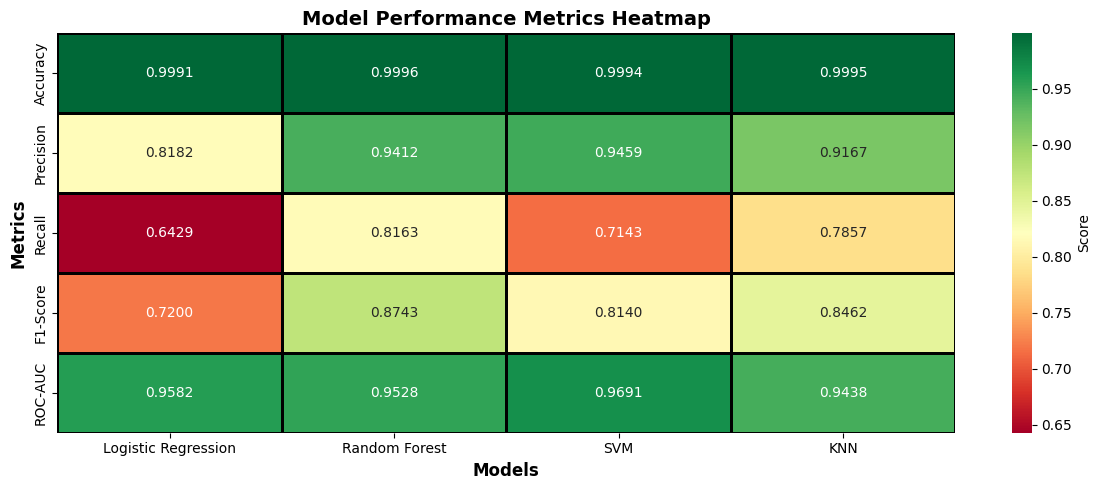


BEST MODELS BY METRIC:
--------------------------------------------------
Accuracy     → Random Forest        (0.9996)
Precision    → SVM                  (0.9459)
Recall       → Random Forest        (0.8163)
F1-Score     → Random Forest        (0.8743)
ROC-AUC      → SVM                  (0.9691)


In [ ]:
# Metrics Comparison Table Visualization
import pandas as pd

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        metrics_data['Logistic Regression']['precision'],
        metrics_data['Random Forest']['precision'],
        metrics_data['SVM']['precision'],
        metrics_data['KNN']['precision']
    ],
    'Recall': [
        metrics_data['Logistic Regression']['recall'],
        metrics_data['Random Forest']['recall'],
        metrics_data['SVM']['recall'],
        metrics_data['KNN']['recall']
    ],
    'F1-Score': [
        metrics_data['Logistic Regression']['f1'],
        metrics_data['Random Forest']['f1'],
        metrics_data['SVM']['f1'],
        metrics_data['KNN']['f1']
    ],
    'ROC-AUC': [
        metrics_data['Logistic Regression']['roc_auc'],
        metrics_data['Random Forest']['roc_auc'],
        metrics_data['SVM']['roc_auc'],
        metrics_data['KNN']['roc_auc']
    ]
})

# Display table
print("\n" + "="*100)
print("COMPREHENSIVE METRICS COMPARISON TABLE")
print("="*100)
print(metrics_df.to_string(index=False))
print("="*100)

# Visualize metrics as heatmap
fig, ax = plt.subplots(figsize=(12, 5))

# Create heatmap
heatmap_data = metrics_df.set_index('Model').T
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax, 
            cbar_kws={'label': 'Score'}, linewidths=1, linecolor='black')

ax.set_title('Model Performance Metrics Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print best model for each metric
print("\nBEST MODELS BY METRIC:")
print("-" * 50)
for metric in metrics_df.columns[1:]:
    best_model = metrics_df.loc[metrics_df[metric].idxmax(), 'Model']
    best_score = metrics_df[metric].max()
    print(f"{metric:12} → {best_model:20} ({best_score:.4f})")

## Step 11: Comprehensive Performance Heatmap
**Summary Visualization:**
- Table format: All metrics (Accuracy, Precision, Recall, F1, AUC) for all 4 models
- Heatmap format: Color-coded performance (Green=High → Red=Low)
- Identifies best model for each individual metric
- Enables holistic comparison of model strengths and weaknesses

## Summary and Key Takeaways

### Understanding the Metrics

**Accuracy**
- Overall correctness across all predictions
- **Limitation**: Misleading for imbalanced datasets (fraud is rare)

**Precision**
- Of all transactions flagged as fraud, what % are genuinely fraudulent?
- **Business Impact**: Reducing false alarms = better customer experience
- Formula: TP / (TP + FP)

**Recall (Sensitivity)**
- Of all actual fraud cases, what % did we catch?
- **Critical for Fraud Detection**: Missing frauds is costly
- Formula: TP / (TP + FN)

**F1-Score**
- Harmonic mean of Precision and Recall
- Single metric balancing both concerns
- Best when precision and recall must be equally weighted

**ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**
- Measures model's ability to distinguish fraud from normal transactions
- Ranges from 0.5 (random) to 1.0 (perfect)
- **Recommended**: Use this for overall model comparison

### Model Selection Guidelines

**Priority 1: Maximize Recall**
- Catching frauds is more important than false alarms
- Missing a fraud = direct financial loss

**Priority 2: Balance Precision**
- Too many false alarms = customer frustration
- Find acceptable false alarm rate

**Best Overall Choice**
- Select model with highest ROC-AUC score
- Or maximize custom metric based on business cost function

### Recommended Next Steps
1. **Model Deployment**: Push best-performing model to production
2. **Threshold Tuning**: Adjust decision boundary based on business needs (recall vs precision trade-off)
3. **Performance Monitoring**: Track metrics in real-world scenarios
4. **Regular Retraining**: Update model monthly/quarterly with new fraud patterns
5. **Feature Engineering**: Create domain-specific features for better detection
6. **Imbalanced Data Techniques**: Consider SMOTE or class weighting for improved learning